In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel("Iqbal.xlsx")

In [3]:
print(data)

        ID                Name  Marks in Quiz\n (Out of 100)  \
0   120001            John Doe                            85   
1   120005          Jane Smith                            92   
2   120017     Michael Johnson                            48   
3   120018         Emily Brown                            90   
4   120022     Daniel Martinez                            75   
5   120024        Sarah Wilson                            88   
6   120025        David Garcia                            75   
7   120027         Jessica Lee                            95   
8   120034       Matthew Davis                            79   
9   120035  Jennifer Rodriguez                            42   
10  120036       Andrew Taylor                            53   
11  120038    Amanda Hernandez                            91   
12  120039   Christopher Clark                            76   
13  120046  Elizabeth Martinez                            89   
14  120047    William Anderson          

In [4]:
data

,ID,Name,Marks in Quiz\n (Out of 100),Mid Term Results (Out of 100),Final Term Resul (Out of 100),Final Score,Grade
0,120001,John Doe,85,78,90,84.44,A
1,120005,Jane Smith,92,88,94,91.38,A
2,120017,Michael Johnson,48,65,56,56.41,C
3,120018,Emily Brown,90,85,88,87.65,A
4,120022,Daniel Martinez,75,80,77,77.35,AB
5,120024,Sarah Wilson,88,70,65,74.01,B
6,120025,David Garcia,75,70,75,73.35,B
7,120027,Jessica Lee,95,91,96,94.03,A
8,120034,Matthew Davis,79,84,78,80.30,AB
9,120035,Jennifer Rodriguez,42,48,63,51.33,C


In [20]:
# Membuat tabel frekuensi Grade
datafreq = pd.crosstab(
    index=data["Grade"],
    columns="Frekuensi"
)

# Menghitung persentase
datafreq["Persentase"] = (
    datafreq["Frekuensi"] / datafreq["Frekuensi"].sum() * 100
)

# Menambahkan tanda % pada persentase
datafreq["Persentase"] = datafreq["Persentase"].round(1)

# Menampilkan tabel
print("======================================")
print("       TABEL FREKUENSI GRADE")
print("======================================")
print(datafreq)
print("======================================")

       TABEL FREKUENSI GRADE
col_0  Frekuensi  Persentase
Grade                       
A             12        40.0
AB             7        23.3
B              4        13.3
BC             1         3.3
C              5        16.7
D              1         3.3


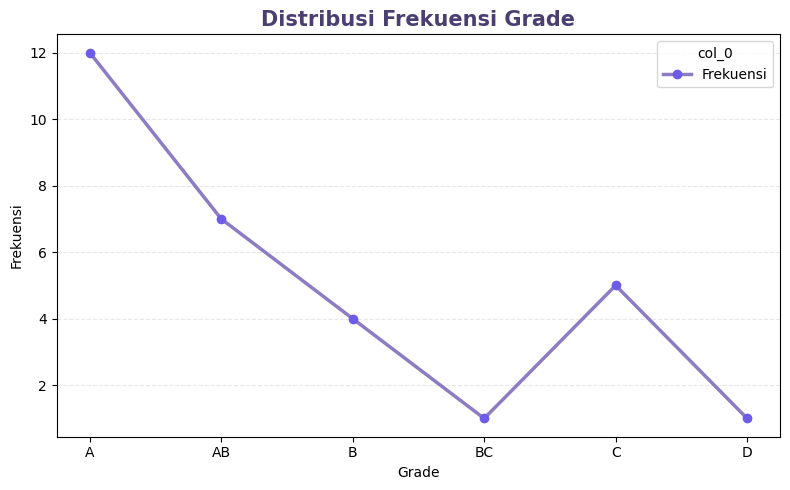

In [8]:
datafreq.plot(
    kind="line",
    marker="o",
    linewidth=2.5,
    figsize=(8, 5),
    color="#8E7CC3",
    markerfacecolor="#6C5CE7",
    markeredgecolor="#6C5CE7"
)

plt.title(
    "Distribusi Frekuensi Grade",
    fontsize=15,
    fontweight="bold",
    color="#4B3F72"
)

plt.xlabel("Grade")
plt.ylabel("Frekuensi")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

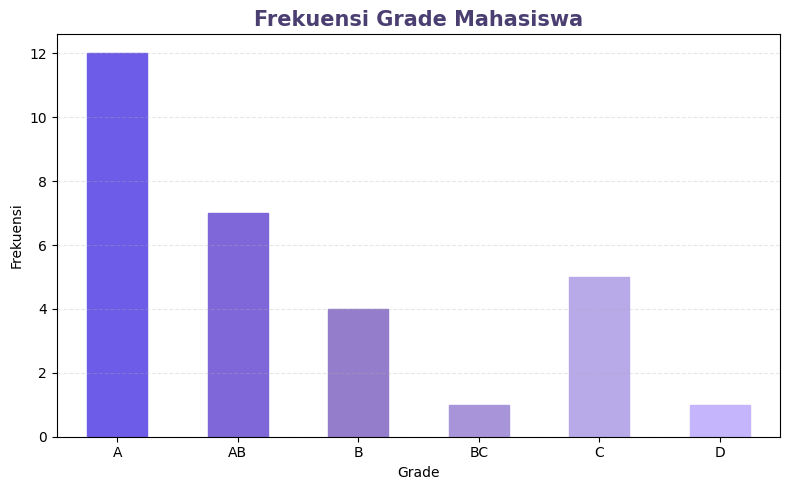

In [9]:
ax = datafreq.plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

colors = [
    "#6C5CE7",
    "#8067D9",
    "#947DCA",
    "#A895D9",
    "#B8A9E8",
    "#C4B5FD"
]

for bar, color in zip(ax.patches, colors):
    bar.set_color(color)

plt.title(
    "Frekuensi Grade Mahasiswa",
    fontsize=15,
    fontweight="bold",
    color="#4B3F72"
)

plt.xlabel("Grade")
plt.ylabel("Frekuensi")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

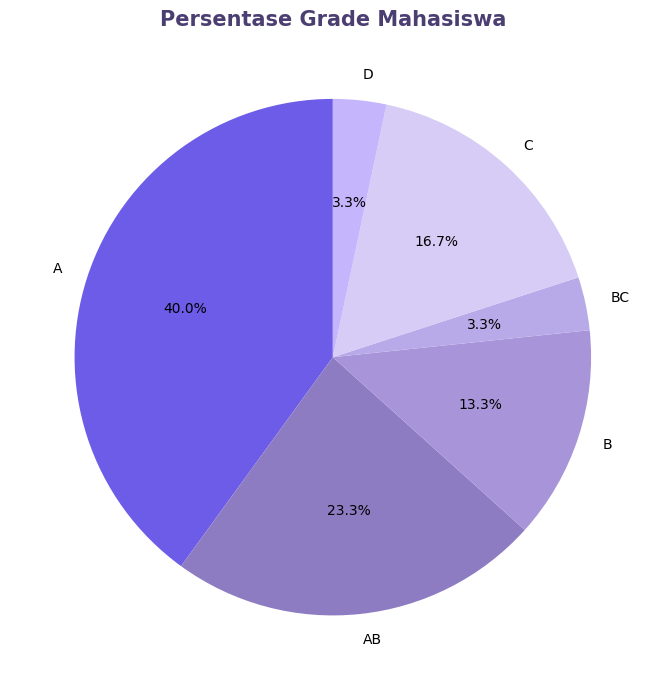

In [10]:
colors = [
    "#6C5CE7",
    "#8E7CC3",
    "#A895D9",
    "#B8A9E8",
    "#D6CCF5",
    "#C4B5FD"
]

datafreq.plot(
    kind="pie",
    y="Frekuensi",
    figsize=(7, 7),
    autopct="%.1f%%",
    colors=colors,
    startangle=90,
    legend=False
)

plt.title(
    "Persentase Grade Mahasiswa",
    fontsize=15,
    fontweight="bold",
    color="#4B3F72"
)

plt.ylabel("")
plt.tight_layout()
plt.show()

In [11]:
data["Final Score"] = pd.to_numeric(
    data["Final Score"],
    errors="coerce"
)

nilai = data["Final Score"].dropna()

In [12]:
stats = {
    "Count": nilai.count(),
    "Mean": nilai.mean(),
    "Standard Error": nilai.sem(),
    "Median": nilai.median(),
    "Mode": nilai.mode().iloc[0],
    "Standard Deviation": nilai.std(),
    "Variance": nilai.var(),
    "Q1 (25%)": nilai.quantile(0.25),
    "Q2 (50%)": nilai.quantile(0.50),
    "Q3 (75%)": nilai.quantile(0.75),
    "Range": nilai.max() - nilai.min(),
    "Minimum": nilai.min(),
    "Maximum": nilai.max(),
    "Skewness": nilai.skew(),
    "Kurtosis": nilai.kurt()
}

stats_df = pd.DataFrame.from_dict(
    stats,
    orient="index",
    columns=["Nilai"]
)

print("=== STATISTIKA DESKRIPTIF ===")
print(stats_df)

=== STATISTIKA DESKRIPTIF ===
                         Nilai
Count                30.000000
Mean                 76.221333
Standard Error        2.458651
Median               78.800000
Mode                 77.300000
Standard Deviation   13.466585
Variance            181.348922
Q1 (25%)             68.095000
Q2 (50%)             78.800000
Q3 (75%)             87.040000
Range                48.020000
Minimum              46.010000
Maximum              94.030000
Skewness             -0.664190
Kurtosis             -0.527463


In [13]:
stats_df.style \
    .format("{:.2f}") \
    .set_caption("Statistika Deskriptif Final Score") \
    .set_properties(
        **{
            "background-color": "#F5F3FF",
            "color": "#3B315B",
            "border": "1px solid #D6CCF5"
        }
    ) \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("background-color", "#6C5CE7"),
                ("color", "white"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#8E7CC3"),
                ("color", "white"),
                ("font-weight", "bold")
            ]
        }
    ])

,Nilai
Count,30.00
Mean,76.22
Standard Error,2.46
Median,78.80
Mode,77.30
Standard Deviation,13.47
Variance,181.35
Q1 (25%),68.09
Q2 (50%),78.80
Q3 (75%),87.04


In [14]:
q1 = nilai.quantile(0.25)
q3 = nilai.quantile(0.75)

iqr = q3 - q1

batas_bawah = q1 - (1.5 * iqr)
batas_atas = q3 + (1.5 * iqr)

print("=== ANALISIS IQR ===")
print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Batas bawah =", batas_bawah)
print("Batas atas =", batas_atas)

=== ANALISIS IQR ===
Q1 = 68.095
Q3 = 87.04
IQR = 18.945000000000007
Batas bawah = 39.67749999999999
Batas atas = 115.45750000000001


In [15]:
outlier = nilai[
    (nilai < batas_bawah) |
    (nilai > batas_atas)
]

print("=== CALON OUTLIER ===")

if len(outlier) == 0:
    print("Tidak terdapat calon outlier.")
else:
    print(outlier)

=== CALON OUTLIER ===
Tidak terdapat calon outlier.


In [16]:
print("========================================")
print("   RINGKASAN STATISTIKA DESKRIPTIF")
print("========================================")

print(f"Jumlah Data       : {nilai.count()}")
print(f"Mean              : {nilai.mean():.2f}")
print(f"Median            : {nilai.median():.2f}")
print(f"Modus             : {nilai.mode().iloc[0]:.2f}")
print(f"Minimum           : {nilai.min():.2f}")
print(f"Maximum           : {nilai.max():.2f}")
print(f"Range             : {nilai.max() - nilai.min():.2f}")
print(f"Q1                : {q1:.2f}")
print(f"Q2                : {nilai.quantile(0.50):.2f}")
print(f"Q3                : {q3:.2f}")
print(f"IQR               : {iqr:.2f}")
print(f"Variance          : {nilai.var():.2f}")
print(f"Standard Deviation: {nilai.std():.2f}")
print(f"Standard Error    : {nilai.sem():.2f}")
print(f"Skewness          : {nilai.skew():.3f}")
print(f"Kurtosis          : {nilai.kurt():.3f}")
print("========================================")

   RINGKASAN STATISTIKA DESKRIPTIF
Jumlah Data       : 30
Mean              : 76.22
Median            : 78.80
Modus             : 77.30
Minimum           : 46.01
Maximum           : 94.03
Range             : 48.02
Q1                : 68.09
Q2                : 78.80
Q3                : 87.04
IQR               : 18.95
Variance          : 181.35
Standard Deviation: 13.47
Standard Error    : 2.46
Skewness          : -0.664
Kurtosis          : -0.527
